In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro

### Проанализируем структуру данных и проведем предобработку:

In [90]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\ab_data_tourist.csv')

In [91]:
df.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


In [92]:
# пропусков нет
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user_id   294478 non-null  int64
 1   date      294478 non-null  str  
 2   group     294478 non-null  str  
 3   purchase  294478 non-null  int64
 4   price     294478 non-null  int64
dtypes: int64(3), str(2)
memory usage: 14.3 MB


In [93]:
print(f'Количество покупателей, которые совершили более 1 покупки в группе A: {df[df['group'] == 'A']['user_id'].duplicated().sum()}')
print(f'Количество покупателей, которые совершили более 1 покупки в группе B: {df[df['group'] == 'B']['user_id'].duplicated().sum()}')

Количество покупателей, которые совершили более 1 покупки в группе A: 1007
Количество покупателей, которые совершили более 1 покупки в группе B: 992


В наших данных есть покупатели, которые принадлежат 1 из групп и совершают более 1 покупки. 

In [94]:
df['date'] = pd.to_datetime(df['date'])

In [95]:
set_users_a = set(df[df['group'] == 'A']['user_id'])
set_users_b = set(df[df['group'] == 'B']['user_id'])
index_for_delete = set_users_a & set_users_b
print(f'Количество покупателей, которые находятся сразу в 2 группах: {len(index_for_delete)}')
# Удаляем покупателей, которые находятся сразу в 2 группах
df_clean = df[~df['user_id'].isin(index_for_delete)]
df_clean

Количество покупателей, которые находятся сразу в 2 группах: 1895


,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000
...,...,...,...,...,...
294473,751197,2021-01-03,A,0,0
294474,945152,2021-01-12,A,0,0
294475,734608,2021-01-22,A,0,0
294476,697314,2021-01-15,A,0,0


In [96]:
# Смотрим дубликаты
print(f'Количество полных дубликатов: {df_clean.duplicated().sum()}')
# Удаляем дубликаты
df_clean.drop_duplicates(inplace=True)
print(f'Количество дубликатов после удаления: {df_clean.duplicated().sum()}')

Количество полных дубликатов: 74
Количество дубликатов после удаления: 0


### Первичный анализ результатов A/B-тестирования

In [97]:
group_ab = df_clean.groupby(['date', 'group']).agg({
    'user_id' : 'count',
    'purchase' : 'sum',
    'price' : 'sum' 
}).rename(columns={'user_id' : 'number_of_visitors',
                   'purchase' : 'count_of_purchase',
                   'price' : 'revenue'}).reset_index()
group_ab.head()

,date,group,number_of_visitors,count_of_purchase,revenue
0,2021-01-02,A,2854,359,29410000
1,2021-01-02,B,2861,345,29660000
2,2021-01-03,A,6595,748,62000000
3,2021-01-03,B,6619,754,65960000
4,2021-01-04,A,6564,799,64250000


Беглый взгляд подсказывает, что данные в двух группах распределены примерно одинаково, тестрование проходило 23 дня, наблюдения за это время есть как в группе А, так и в группе B. Выборки сбалансированы.

In [98]:
# Расчет конверсии и среднего чека
group_ab['conversion'] = np.round(group_ab['count_of_purchase'] / group_ab['number_of_visitors'], 3)
group_ab['mean_check'] = (group_ab['revenue'] / group_ab['count_of_purchase']).astype('int')
group_ab.head()

,date,group,number_of_visitors,count_of_purchase,revenue,conversion,mean_check
0,2021-01-02,A,2854,359,29410000,0.126,81922
1,2021-01-02,B,2861,345,29660000,0.121,85971
2,2021-01-03,A,6595,748,62000000,0.113,82887
3,2021-01-03,B,6619,754,65960000,0.114,87480
4,2021-01-04,A,6564,799,64250000,0.122,80413


In [99]:
print(f'Конверсия в группе А: {group_ab[group_ab['group'] == 'A']['conversion'].tolist()[:10]}')
print(f'Конверсия в группе B: {group_ab[group_ab['group'] == 'B']['conversion'].tolist()[:10]}')

Конверсия в группе А: [0.126, 0.113, 0.122, 0.123, 0.116, 0.121, 0.119, 0.12, 0.114, 0.119]
Конверсия в группе B: [0.121, 0.114, 0.117, 0.115, 0.124, 0.116, 0.121, 0.118, 0.126, 0.115]


In [100]:
print(f'Средний чек в группе А: {group_ab[group_ab['group'] == 'A']['mean_check'].tolist()[:10]}')
print(f'Средний чек в группе B: {group_ab[group_ab['group'] == 'B']['mean_check'].tolist()[:10]}')

Средний чек в группе А: [81922, 82887, 80413, 81708, 82997, 84641, 81929, 82632, 77667, 73726]
Средний чек в группе B: [85971, 87480, 89044, 84846, 89522, 87574, 87770, 91084, 92293, 86961]


Конверсии в обеих группах примерно одинаковы, а вот средний чек в B кажется заметно выше.

In [101]:
group_tour = pd.pivot_table(
    data=df,
    columns='group',
    index='price',
    values='user_id',
    aggfunc='count')
group_tour

group,A,B
price,,
0,129479,129762
10000,5253,5257
60000,5343,1748
100000,1859,5311
150000,3527,3481
200000,1741,1717


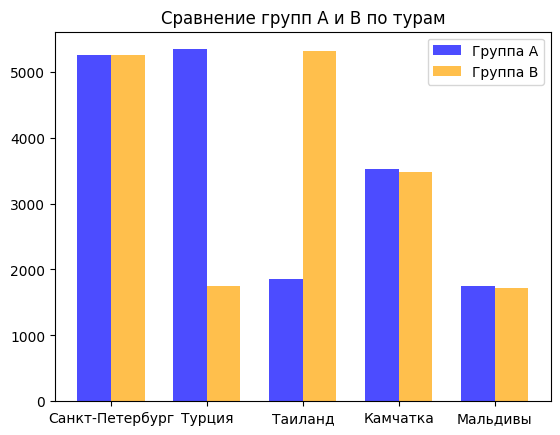

In [102]:
x = np.arange(len(group_tour.loc[1:]))
width = 0.35
bars_a = plt.bar(x - width/2, group_tour.loc[1:]['A'], width, label='Группа А', color='blue', alpha=0.7)
bars_b = plt.bar(x + width/2, group_tour.loc[1:]['B'], width, label='Группа B', color='orange', alpha=0.7)
plt.xticks(x, ['Санкт-Петербург', 'Турция', 'Таиланд', 'Камчатка', 'Мальдивы'])
plt.title('Сравнение групп А и В по турам')
plt.legend()
plt.show()

По графику видим, что по всем группам показатели примерно одинаковы, однако в для туров в Турцию и Тайланд ситуация иная, различные виды посадочных страниц сильно влияют на покупателей, которые склоны к путешествиям именно в эти страны.

In [103]:
group_ab_A = group_ab[group_ab['group'] == 'A']
group_ab_B = group_ab[group_ab['group'] == 'B']
# Кумулятивное количество посетителей
group_ab_A['cumsum_visitors'] = group_ab_A['number_of_visitors'].cumsum()
group_ab_B['cumsum_visitors'] = group_ab_B['number_of_visitors'].cumsum()
# Кумулятивное количество покупок
group_ab_A['cumsum_purchase'] = group_ab_A['count_of_purchase'].cumsum()
group_ab_B['cumsum_purchase'] = group_ab_B['count_of_purchase'].cumsum()
# Кумулятивная сумма покупок
group_ab_A['cumsum_revenue'] = group_ab_A['revenue'].cumsum()
group_ab_B['cumsum_revenue'] = group_ab_B['revenue'].cumsum()
# Кумулятивная конверсия 
group_ab_A['cumsum_conversion'] = np.round(group_ab_A['cumsum_purchase'] / group_ab_A['cumsum_visitors'], 4)
group_ab_B['cumsum_conversion'] = np.round(group_ab_B['cumsum_purchase'] / group_ab_B['cumsum_visitors'], 4)
# Кумулятивный средний чек
group_ab_A['cumsum_mean_check'] = np.round(group_ab_A['cumsum_revenue'] / group_ab_A['cumsum_purchase'])
group_ab_B['cumsum_mean_check'] = np.round(group_ab_B['cumsum_revenue'] / group_ab_B['cumsum_purchase'])

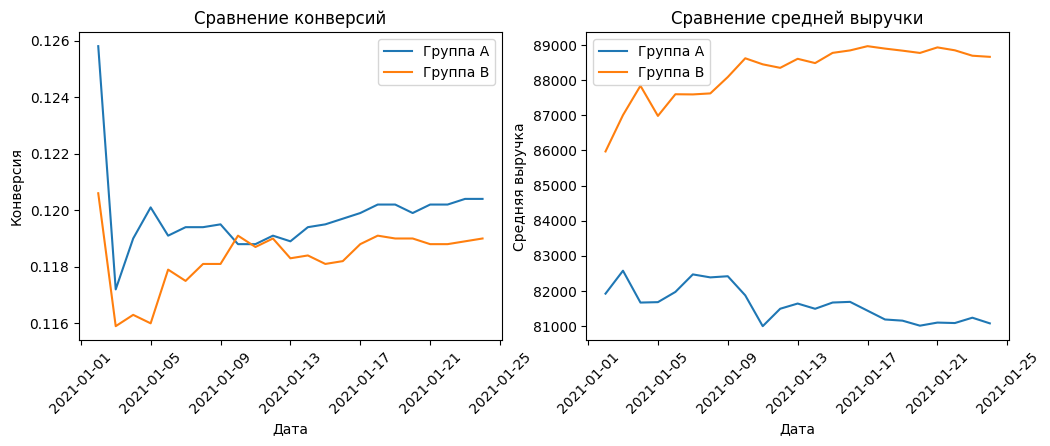

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.title('Сравнение кумулятивных конверсий по группам')
sns.lineplot(x=group_ab_A['date'], y=group_ab_A['cumsum_conversion'], label='Группа А', ax=axes[0])
sns.lineplot(x=group_ab_B['date'], y=group_ab_B['cumsum_conversion'], label='Группа B', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Сравнение конверсий')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Конверсия')

sns.lineplot(x=group_ab_A['date'], y=group_ab_A['cumsum_mean_check'], label='Группа А', ax=axes[1])
sns.lineplot(x=group_ab_B['date'], y=group_ab_B['cumsum_mean_check'], label='Группа B', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Средняя выручка')
axes[1].set_title('Сравнение средней выручки')
plt.show()

По графикам можно сделать следующие выводы:
- Конверсия в группе A практически всегда выше, чем в группе B
- Средний чек после стабилизации показывает, что в группе B результат заметно лучше, чем в A.

## Статистическая проверка

In [105]:
# Проверка на нормальность
conversion_A = group_ab_A['conversion']
conversion_B = group_ab_B['conversion']
mean_check_A = group_ab_A['mean_check']
mean_check_B = group_ab_B['mean_check']

alpha = 0.05
for name, data in [('конверсии в группе A', conversion_A),
                   ('конверсии в группе B', conversion_B),
                   ('среднего чека в группе A', mean_check_A),
                   ('среднего чека в группе B', mean_check_B)]:
    _, p = shapiro(data)
    if p < alpha:
        print(f'Отклоняем нулевую гипотезу о нормальности распределения для {name}, p={np.round(p, 3)}')
    else:
        print(f'Принимаем нулевую гипотезу о нормальности распределения для {name}, p={np.round(p, 3)}')

Принимаем нулевую гипотезу о нормальности распределения для конверсии в группе A, p=0.222
Принимаем нулевую гипотезу о нормальности распределения для конверсии в группе B, p=0.834
Принимаем нулевую гипотезу о нормальности распределения для среднего чека в группе A, p=0.253
Принимаем нулевую гипотезу о нормальности распределения для среднего чека в группе B, p=0.094


Гипотеза:

H0: Конверсии в группе A и группе B равны

H1: Конверсии в группе A и группе B не равны

In [106]:
from statsmodels.stats.proportion import proportions_ztest
_, p = proportions_ztest(count=[group_ab_A['count_of_purchase'].sum(), group_ab_B['count_of_purchase'].sum()],
                         nobs=[group_ab_A['number_of_visitors'].sum(), group_ab_B['number_of_visitors'].sum()],
                         alternative='two-sided')

print(f'p-value: {np.round(p, 3)}')
if p < alpha:
    print('Отвергаем нулевую гипотезу. Конверсии в группах не равны')
else:
    print('Принимаем нулевую гипотезу. Конверсии в группах равны')



p-value: 0.238
Принимаем нулевую гипотезу. Конверсии в группах равны


Гипотеза:

H0: Конверсия в группе B больше или равна, чем в A

H1: Конверсия в группе B меньше конверсии в A

In [107]:
_, p = proportions_ztest(count=[group_ab_A['count_of_purchase'].sum(), group_ab_B['count_of_purchase'].sum()],
                         nobs=[group_ab_A['number_of_visitors'].sum(), group_ab_B['number_of_visitors'].sum()], 
                               alternative='smaller') 

if p < alpha:
    print('Отвергаем нулевую гипотезу. Конверсия в B меньше, чем в A')
else:
    print('Принимаем нулевую гипотезу. Конверсия в B больше или равна, чем в A')

Принимаем нулевую гипотезу. Конверсия в B больше или равна, чем в A


Гипотеза:

H0: P_a - P_b = 0

H1: P_a - P_b != 0

In [108]:
from statsmodels.stats.proportion import proportions_chisquare
_, p, _ = proportions_chisquare(count=[group_ab_A['count_of_purchase'].sum(), group_ab_B['count_of_purchase'].sum()],
                         nobs=[group_ab_A['number_of_visitors'].sum(), group_ab_B['number_of_visitors'].sum()])
if p < alpha:
    print('Отвергаем нулевую гипотезу. Конверсии не равны между собой')
else:
    print('Принимаем нулевую гипотезу. Конверсии в группах равны.')

Принимаем нулевую гипотезу. Конверсии в группах равны.


Мы провели 3 статистических теста и во всех получили, что конверсии в группах равны. 

In [109]:
# Построим доверительный интервал
from scipy.stats import norm
def proportion_conf_interval(x_p, n, gamma=0.95):  
    alpha = 1 - gamma # уровень значимости
    z_crit = -norm.ppf(alpha/2) # z-критическое
    eps = z_crit * (x_p * (1 - x_p) / n) ** 0.5 # погрешность
    lower_bound = x_p - eps # левая (нижняя) граница
    upper_bound = x_p + eps # правая (верхняя) граница
    # возвращаем кортеж из границ интервала
    return lower_bound, upper_bound

lower_bound_a, upper_bound_a  = proportion_conf_interval(
    x_p=group_ab_A['conversion'].mean(),
    n=group_ab_A['conversion'].count())

lower_bound_b, upper_bound_b  = proportion_conf_interval(
    x_p=group_ab_B['conversion'].mean(),
    n=group_ab_B['conversion'].count())
print(f'Доверительный интервал для конверсии в группе A: [{np.round(lower_bound_a, 3)} , {np.round(upper_bound_a, 3)}]')
print(f'Доверительный интервал для конверсии в группе B: [{np.round(lower_bound_b, 3)} , {np.round(upper_bound_b, 3)}]')

Доверительный интервал для конверсии в группе A: [-0.013 , 0.254]
Доверительный интервал для конверсии в группе B: [-0.013 , 0.251]


Доверительные интервалы для конверсий практически идентичны.

In [110]:
# Доверительный интервал для разности пропорций
def diff_proportion_conf_interval(x_p, n, gamma=0.95):
    alpha = 1 - gamma # уровень значимости
    diff = x_p[1] - x_p[0] # выборочная разница конверсий групп B и A
    z_crit = -norm.ppf(alpha/2) #z-критическое
    eps = z_crit * (x_p[0] * (1 - x_p[0])/n[0] + x_p[1] * (1 - x_p[1])/n[1]) ** 0.5 # погрешность
    lower_bound = diff - eps # левая (нижняя) граница
    upper_bound = diff + eps # правая (верхняя) граница
    # возвращаем кортеж из  границ интервала
    return lower_bound, upper_bound

n = [group_ab_A['conversion'].count(), group_ab_B['conversion'].count()]
x_p = [group_ab_A['conversion'].mean(), group_ab_B['conversion'].mean()]


# строим доверительный интервал для разности пропорций
lower_bound, upper_bound = diff_proportion_conf_interval(x_p=x_p, n=n)
print(f'Доверительный интервал для разности пропорций: [{np.round(lower_bound, 3)} ; {np.round(upper_bound, 3)}]')


Доверительный интервал для разности пропорций: [-0.189 ; 0.186]


Интервал содержит 0, кроме того, он практически симметричен относительно 0, следовательно разница между конверсиями не значима

Доверительные интервалы и доверительный интервал разности пропорций нам также показывают, что конверсии в группах равны.

### Анализ средних чеков по группам

Гипотеза:

H0: Средние чеки в группах равны

H1: Средние чеки в группах отличаются

In [111]:
from scipy.stats import ttest_ind

_, p = ttest_ind(a=group_ab_A['mean_check'], 
                 b=group_ab_B['mean_check'])
print(f'p-value: {np.round(p, 3)}')
if p < alpha:
    print('Отвергаем нулевую гипотезу. Средние чеки в группах не равны.')
else:
    print('Принимаем нулевую гипотезу. Средние чеки в группах равны.')




p-value: 0.0
Отвергаем нулевую гипотезу. Средние чеки в группах не равны.


Гипотеза:

H0: В группе A средний чек больше или равен среднему чеку в группе B. 

H1: В группе A средний чек меньше среднего чека в группе B. 


In [112]:
_, p = ttest_ind(a=group_ab_A['mean_check'], 
                 b=group_ab_B['mean_check'], 
                 alternative='less')
print(f'p-value: {np.round(p, 3)}')
if p < alpha:
    print('Отвергаем нулевую гипотезу. Средний чек в группе A меньше среднего чека в группе B')
else:
    print('Принимаем нулевую гипотезу. В группе A средний чек больше или равен среднему чеку в группе B. ')



p-value: 0.0
Отвергаем нулевую гипотезу. Средний чек в группе A меньше среднего чека в группе B


In [113]:
# Доверительный интервал
def z_mean_conf_interval(x_mean, sigma, n, gamma=0.95):  
    alpha = 1 - gamma  # уровень значимости
    z_crit = -norm.ppf(alpha/2)  # z-критическое
    eps = z_crit * sigma/(n ** 0.5) # погрешность
    lower_bound = x_mean - eps  # левая (нижняя) граница
    upper_bound = x_mean + eps  # правая (верхняя) граница
    # возвращаем кортеж из границ интервала
    return lower_bound, upper_bound

x_mean_a = np.mean(group_ab_A['mean_check'])
sigma_a = np.std(group_ab_A['mean_check'])
n = len(group_ab_B)
lower_bound_a, upper_bound_a = z_mean_conf_interval(x_mean_a, sigma_a, n)
x_mean_b = np.mean(group_ab_B['mean_check'])
sigma_b = np.std(group_ab_B['mean_check'])
lower_bound_b, upper_bound_b = z_mean_conf_interval(x_mean_b, sigma_b, n)

print(f'Доверительный интервал для среднего из группы A: [{np.round(lower_bound_a)}, {np.round(upper_bound_a)}]')
print(f'Доверительный интервал для среднего из группы B: [{np.round(lower_bound_b)}, {np.round(upper_bound_b)}]')

Доверительный интервал для среднего из группы A: [79731.0, 82206.0]
Доверительный интервал для среднего из группы B: [87697.0, 89453.0]


Получаем, что доверительный интервал для среднего из группы A лежит левее, чем доверительный интервал для группы B. 
Следовательно, средний чек в группе B статистически выше, чем в группе A.

Первичный визуальный анализ и статистический анализ показали в процессе исследования похожие выводы. Конверсии для групп не имеют статистических различий, зато мы обнаружили существенную разницу в среднем чеке для группы B.

Вывод для бизнеса:
Компании стоит принять решение о внедрении новой посадочной страницы, которую показывали группе B. Конверсия у бизнеса статистически значимо не увеличится, но вырастет средний чек.